# EDA Test_transaction

## Test_transaction

In [2]:
# -----------------------------------------------------------
# 1. Paquetes necesarios para el análisis
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency, ttest_ind

In [3]:
# -----------------------------------------------------------------------
# 2. Cargar los datos de test_transaction desde nuestro disco duro local
#    cambia la ruta a la ubicación de tu archivo CSV
# -----------------------------------------------------------------------

test_transaction = pd.read_csv(r"C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/fraude/test_transaction.csv")

# -----------------------------------------------------------------------
# 3. Inspeccionar los datos cargados
# -----------------------------------------------------------------------

test_transaction

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.950,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.000,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.950,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.950,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506686,4170235,34214279,94.679,C,13832,375.0,185.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506687,4170236,34214287,12.173,C,3154,408.0,185.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506688,4170237,34214326,49.000,W,16661,490.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
506689,4170238,34214337,202.000,W,16621,516.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


TEST TRANSACTION 

Estructura de la Base de Datos
Filas y Columnas:

La base de datos contiene 506,691 filas y 393 columnas. Esto indica un conjunto de datos bastante grande y complejo.
Columnas Principales:

TransactionID: Un identificador único para cada transacción. Es crucial para rastrear y referenciar transacciones individuales.
TransactionDT: La fecha y hora de la transacción, representada como un número entero. Este campo es esencial para el análisis temporal.
TransactionAmt: El monto de la transacción. Es una variable continua que puede ser útil para análisis financieros y detección de fraudes.
ProductCD: Un código que representa el tipo de producto involucrado en la transacción. Puede ser categórico y útil para segmentar los datos por tipo de producto.
card1 a card6: Información relacionada con la tarjeta utilizada en la transacción. Estos campos pueden incluir detalles como el número de tarjeta (posiblemente encriptado), el tipo de tarjeta, el emisor, etc.
V330 a V339: Estas columnas parecen ser variables adicionales, posiblemente características anonimizadas o codificadas. Los valores NaN indican que estas columnas pueden tener datos faltantes o no aplicables para ciertas transacciones.
Conclusión
Esta base de datos ofrece una rica fuente de información para el análisis transaccional. A través de un EDA detallado y consideraciones estadísticas, se pueden extraer insights valiosos que pueden informar decisiones estratégicas, mejorar la detección de fraudes y optimizar las operaciones comerciales.

In [4]:
# -----------------------------------------------------------------------
# 4. Cargar los datos de test_identity desde nuestro disco duro local
#    cambia la ruta a la ubicación de tu archivo CSV
# -----------------------------------------------------------------------

test_identity = pd.read_csv(r"C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/fraude/test_identity.csv")

# -----------------------------------------------------------------------
# 5. Inspeccionar los datos cargados
# -----------------------------------------------------------------------

test_identity

,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,...,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,...,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141902,4170230,-20.0,473365.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J700M
141903,4170233,-5.0,489917.0,0.0,0.0,-4.0,-32.0,NaN,NaN,0.0,...,chrome 71.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-J320M
141904,4170234,-5.0,110081.0,NaN,NaN,22.0,-31.0,NaN,NaN,NaN,...,mobile safari 10.0,32.0,1334x750,match_status:2,T,F,F,T,mobile,iOS Device
141905,4170236,-45.0,266704.0,NaN,NaN,-3.0,-10.0,NaN,NaN,NaN,...,chrome 43.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,ALE-L23 Build/HuaweiALE-L23


Estructura de la Base de Datos
Filas y Columnas:

La base de datos contiene 141,907 filas y 41 columnas. Esto indica un conjunto de datos moderadamente grande.
Columnas Principales:

TransactionID: Un identificador único para cada transacción. Es crucial para rastrear y referenciar transacciones individuales.
id-01 a id-38: Estas columnas parecen ser identificadores o características adicionales relacionadas con la transacción. Algunas de estas columnas tienen valores numéricos, mientras que otras tienen valores categóricos o booleanos (T/F).
DeviceType: Indica el tipo de dispositivo utilizado en la transacción (por ejemplo, "mobile", "desktop"). Esta información es útil para segmentar el análisis por tipo de dispositivo.
DeviceInfo: Proporciona detalles adicionales sobre el dispositivo, como el modelo y el sistema operativo. Esto puede ser útil para identificar patrones específicos de dispositivos.
 esta es un commplemento de la base anterior trabajada.

In [5]:
# -----------------------------------------------------------------------
# 7. Paquetes necesarios para medir el tiempo de ejecución
# -----------------------------------------------------------------------

import time
import pandas as pd

# Lista para almacenar los tiempos de ejecución
execution_times = []

#-------------------------------------------------------------------------
# 8. Fusionar los dos conjuntos de datos test_transaction y test_identity en uno solo para redefinir FD_test
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

FD_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Fusión de DataFrames", elapsed_time))

#-------------------------------------------------------------------------
# 7. Guardar el DataFrame fusionado en un archivo CSV en la ruta especificada
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

FD_test.to_csv("C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/FD_test.csv", index=False)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Guardado del CSV", elapsed_time))

#-------------------------------------------------------------------------
# 8. Inspeccionar los datos fusionados
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

print(FD_test.head())  # Muestra las primeras filas del DataFrame

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Inspección de datos", elapsed_time))

#-------------------------------------------------------------------------
# 9. Mostrar los tiempos de ejecución en una tabla
#    Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

# ----------------------------------------------------------
# 10. Crear un DataFrame para mostrar los tiempos
# ----------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print(times_df)


   TransactionID  TransactionDT  TransactionAmt ProductCD  card1  card2  \
0        3663549       18403224           31.95         W  10409  111.0   
1        3663550       18403263           49.00         W   4272  111.0   
2        3663551       18403310          171.00         W   4476  574.0   
3        3663552       18403310          284.95         W  10989  360.0   
4        3663553       18403317           67.95         W  18018  452.0   

   card3       card4  card5  card6  ...  id-31  id-32  id-33  id-34 id-35  \
0  150.0        visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   
1  150.0        visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   
2  150.0        visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   
3  150.0        visa  166.0  debit  ...    NaN    NaN    NaN    NaN   NaN   
4  150.0  mastercard  117.0  debit  ...    NaN    NaN    NaN    NaN   NaN   

  id-36  id-37  id-38  DeviceType  DeviceInfo  
0   NaN    NaN    NaN         NaN     

La tabla presentada muestra un extracto de un conjunto de datos transaccionales con 5 filas y 433 columnas, proporcionando una visión detallada de diversas características de las transacciones. Cada fila representa una transacción única identificada por `TransactionID`, con columnas adicionales que incluyen la fecha y hora de la transacción (`TransactionDT`), el monto de la transacción (`TransactionAmt`), el tipo de producto (`ProductCD`), y detalles de la tarjeta utilizada (`card1` a `card6`). Además, la tabla incluye identificadores numéricos adicionales (`id-01` a `id-38`), tipo de dispositivo (`DeviceType`) e información específica del dispositivo (`DeviceInfo`). Los datos muestran una variedad de valores, incluyendo algunos faltantes (`NaN`), lo que sugiere la necesidad de manejo de datos faltantes. El proceso de fusión de DataFrames tomó 18 segundos, mientras que la guardar el archivo CSV tomó 2 minutos y 18 segundos, y la inspección de datos se realizó en menos de un segundo. En conjunto, esta tabla ofrece una rica fuente de información para el análisis transaccional, destacando la diversidad de dispositivos y sistemas operativos utilizados, así como la presencia de datos faltantes que deben ser considerados en cualquier análisis posterior.

In [ ]:
#-------------------------------------------------------------------------
# 11. Importar los paquetes necesarios
#-------------------------------------------------------------------------

import zipfile
import pandas as pd
import time

#-------------------------------------------------------------------------
# 12. Leer el archivo CSV 'FD2.csv' desde el ZIP
#     Ruta al archivo ZIP
#-------------------------------------------------------------------------

zip_path = "C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/Fraude_Data_FD1_FD2.zip"

#-------------------------------------------------------------------------
# 13. Lista para almacenar los tiempos de ejecución
# --------------------------------------------------------------------------

execution_times = []

start_time = time.time()  # Iniciar el cronómetro

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('FD2.csv') as file:
        FD2 = pd.read_csv(file)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Lectura del CSV", elapsed_time))

#-------------------------------------------------------------------------
# 14. Mostrar el DataFrame FD2
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

print(FD2.head())  # Muestra las primeras filas del DataFrame

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Visualización del DataFrame", elapsed_time))

#-------------------------------------------------------------------------
# 15. Mostrar los tiempos de ejecución en una tabla
#     Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

#-------------------------------------------------------------------------
# 16. Crear un DataFrame para mostrar los tiempos
#-------------------------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


   TransID   TransDT  TransAmt ProdCD  card1  card2  card3       card4  card5  \
0  3663549  18403224     31.95      W  10409  111.0  150.0        visa  226.0   
1  3663550  18403263     49.00      W   4272  111.0  150.0        visa  226.0   
2  3663551  18403310    171.00      W   4476  574.0  150.0        visa  226.0   
3  3663552  18403310    284.95      W  10989  360.0  150.0        visa  166.0   
4  3663553  18403317     67.95      W  18018  452.0  150.0  mastercard  117.0   

   card6  ...  id-31  id-32  id-33  id-34 id-35 id-36  id-37  id-38  DevType  \
0  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN    NaN    NaN      NaN   
1  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN    NaN    NaN      NaN   
2  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN    NaN    NaN      NaN   
3  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN    NaN    NaN      NaN   
4  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN    NaN    NaN      NaN   

   DevInfo  
0      NaN  
1     

Número de observaciones (reemplazar a apartir de aquí con el dataframe - test)

Al explorar este extenso conjunto de datos de 433 columnas, encontramos numerosos valores faltantes dispersos en múltiples características. Los datos transaccionales muestran información financiera (TransAmt), diversos detalles de tarjetas (card1-card6), códigos de productos y múltiples características de ID. Al examinar las fechas de transacción (TransDT), identificamos patrones temporales en las actividades financieras. El análisis inicial muestra una estructura compleja con diversos tipos de datos que requieren preprocesamiento específico. La naturaleza de los datos sugiere un problema de detección de fraude, donde se observa un desequilibrio de clases característico. Las columnas como card4 y card6 indican el tipo de tarjeta y método de pago, proporcionando contexto valioso para entender los patrones de transacción. La presencia de numerosas columnas id-XX sugiere características derivadas o anónimas que podrían contener información relevante para identificar transacciones fraudulentas.

In [7]:
#-------------------------------------------------------------------------
# 17. Importar los paquetes necesarios
#-------------------------------------------------------------------------

import pandas as pd
import time

#-------------------------------------------------------------------------
# 18. Calcular el número de observaciones no nulas y el porcentaje de valores faltantes
#     Lista para almacenar los tiempos de ejecución
#-------------------------------------------------------------------------

execution_times = []
start_time = time.time()  # Iniciar el cronómetro

#-------------------------------------------------------------------------
# 19. Calcular el número de observaciones no nulas y el porcentaje de valores faltantes
# -------------------------------------------------------------------------

num_obs = FD2.count()

#-------------------------------------------------------------------------
# 20. Total de filas (observaciones en el DataFrame)
#-------------------------------------------------------------------------

total_rows = FD2.shape[0]

#-------------------------------------------------------------------------
# 21. Calcular el porcentaje de valores faltantes por columna
#-------------------------------------------------------------------------

missing_pct = ((total_rows - num_obs) / total_rows * 100).round(2)

#-------------------------------------------------------------------------
# 22. Unir en un solo DataFrame
# --------------------------------------------------------------------------

obs_summary = pd.DataFrame({
    'non_null_count': num_obs,
    'missing_percentage': missing_pct
})

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Cálculo de observaciones y valores faltantes", elapsed_time))

#-------------------------------------------------------------------------
# 23. Mostrar el resumen de observaciones
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

print(obs_summary)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Visualización del resumen de observaciones", elapsed_time))

#-------------------------------------------------------------------------
# 24. Mostrar los tiempos de ejecución en una tabla
#     Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

#-------------------------------------------------------------------------
# 25. Crear un DataFrame para mostrar los tiempos
#-------------------------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


          non_null_count  missing_percentage
TransID           506691                0.00
TransDT           506691                0.00
TransAmt          506691                0.00
ProdCD            506691                0.00
card1             506691                0.00
...                  ...                 ...
id-36             136977               72.97
id-37             136977               72.97
id-38             136977               72.97
DevType           136931               72.98
DevInfo           115057               77.29

[433 rows x 2 columns]

Tiempos de ejecución:
                                    Descripción     Tiempo Transcurrido
0  Cálculo de observaciones y valores faltantes  0 minutos y 2 segundos
1    Visualización del resumen de observaciones  0 minutos y 0 segundos


Nuestro grupo analizó la estructura del conjunto de datos de detección de fraude y encontró que contiene 506,691 transacciones con 433 variables. El conjunto presenta un patrón interesante de valores faltantes: mientras las columnas principales como TransID, TransDT, TransAmt, ProdCD y card1 están completas (0% de valores faltantes), observamos un incremento gradual en el porcentaje de datos ausentes en otras características. Las variables más afectadas incluyen DevInfo con 77.29% de valores faltantes, seguido por DevType con 72.98%, y varias columnas de identificación (id-36, id-37, id-38) con aproximadamente 72.97% de datos ausentes. Este patrón sugiere una estructura de datos donde ciertas características solo son relevantes para tipos específicos de transacciones, lo que explica la naturaleza sistemática de los valores faltantes. El análisis de estos patrones será crucial para desarrollar estrategias efectivas de modelado en nuestro proyecto de detección de fraude.

In [8]:
#-------------------------------------------------------------------------
# 26. Importar los paquetes necesarios
#-------------------------------------------------------------------------

import pandas as pd
import time

#-------------------------------------------------------------------------
# 27. Calcular estadísticas básicas para columnas numéricas
#-------------------------------------------------------------------------

#--------------------------------------------------------------------------
# 28. Lista para almacenar los tiempos de ejecución
#--------------------------------------------------------------------------

execution_times = []

start_time = time.time()  # Iniciar el cronómetro

# Calcular estadísticas básicas para columnas numéricas
estadisticas_numericas = FD2.describe()

print("Estadísticas básicas para columnas numéricas:")
print(estadisticas_numericas)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Cálculo de estadísticas numéricas", elapsed_time))

#-------------------------------------------------------------------------
# 29. Filtrar solo columnas numéricas y calcular estadísticas para columnas no numéricas
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

#--------------------------------------------------------------------------
# 30. Filtrar solo columnas numéricas
#--------------------------------------------------------------------------

columnas_numericas = FD2.select_dtypes(include=['number'])

#--------------------------------------------------------------------------
# 31. Calcular estadísticas para columnas no numéricas (categóricas)
#--------------------------------------------------------------------------

estadisticas_categoricas = FD2.describe(include='object')

print("\nEstadísticas básicas para columnas no numéricas:")
print(estadisticas_categoricas)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Cálculo de estadísticas categóricas", elapsed_time))

#-------------------------------------------------------------------------
# 32. Mostrar los tiempos de ejecución en una tabla
#     Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

#-------------------------------------------------------------------------
# 33. Crear un DataFrame para mostrar los tiempos
#-------------------------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


Estadísticas básicas para columnas numéricas:
            TransID       TransDT       TransAmt          card1  \
count  5.066910e+05  5.066910e+05  506691.000000  506691.000000   
mean   3.916894e+06  2.692994e+07     134.725568    9957.222175   
std    1.462692e+05  4.756507e+06     245.779822    4884.960969   
min    3.663549e+06  1.840322e+07       0.018000    1001.000000   
25%    3.790222e+06  2.277154e+07      40.000000    6019.000000   
50%    3.916894e+06  2.720466e+07      67.950000    9803.000000   
75%    4.043566e+06  3.134856e+07     125.000000   14276.000000   
max    4.170239e+06  3.421434e+07   10270.000000   18397.000000   

               card2          card3          card5          addr1  \
count  498037.000000  503689.000000  502144.000000  441082.000000   
mean      363.735379     153.543409     200.162975     291.846514   
std       158.688653      12.443013      40.562461     102.062730   
min       100.000000     100.000000     100.000000     100.000000   
25%  

El equipo de análisis examinó el conjunto de datos de detección de fraude y encontró estadísticas reveladoras para sus 506,691 transacciones. Las columnas numéricas muestran una amplia variación en montos de transacción (TransAmt) con un promedio de $134.73 y valores que oscilan entre $0.02 hasta $10,270. Observamos patrones interesantes en las variables de tarjetas, donde card3 muestra poca variabilidad (mayoría en 150) mientras que card1 y card2 presentan distribuciones más amplias. Entre las variables categóricas, el producto W es predominante (360,987 casos), las tarjetas visa son las más comunes (334,882), y el tipo de tarjeta más frecuente es débito (385,021). Gmail.com aparece como el proveedor de correo electrónico más utilizado tanto para remitentes como destinatarios. Varias columnas binarias (M1-M5) muestran desequilibrios significativos, y Windows es el sistema operativo más común. La resolución de pantalla predominante es 1920x1080, y la mayoría de los dispositivos son de escritorio. Estos patrones proporcionan insights valiosos para nuestro modelo de detección de fraude.

In [9]:
# Calcular asimetría y curtosis solo para las columnas numéricas
asimetria = columnas_numericas.skew()
curtosis = columnas_numericas.kurt()

print("/nAsimetría de las columnas numéricas:")
print(asimetria)

print("/nCurtosis de las columnas numéricas:")
print(curtosis)

/nAsimetría de las columnas numéricas:
TransID     8.576270e-16
TransDT    -1.461656e-01
TransAmt    8.600886e+00
card1      -5.764174e-02
card2      -2.145919e-01
                ...     
id-22       4.148039e+00
id-24       1.675694e+00
id-25       7.099090e-02
id-26       1.528108e-01
id-32       9.556708e-01
Length: 402, dtype: float64
/nCurtosis de las columnas numéricas:
TransID      -1.200000
TransDT      -1.265032
TransAmt    129.336773
card1        -1.139890
card2        -1.339535
               ...    
id-22        15.663045
id-24         2.578678
id-25         0.499980
id-26        -0.568686
id-32        -0.871534
Length: 402, dtype: float64


Nuestro equipo analizó la distribución de las 402 variables numéricas del conjunto de datos de fraude, encontrando patrones importantes en su asimetría y curtosis. La mayoría de las variables muestran asimetría significativa, destacando especialmente TransAmt con un valor extremadamente alto (8.60), indicando una fuerte concentración de transacciones de bajo valor con algunas de valor muy alto. La curtosis confirma esta observación, mostrando que TransAmt tiene una distribución leptocúrtica extrema (129.34), muy alejada de una distribución normal. Variables como id-22 también presentan asimetría positiva considerable (4.15) y alta curtosis (15.66), sugiriendo distribuciones con valores atípicos significativos. En contraste, variables como TransID, TransDT, card1 y card2 muestran asimetría cercana a cero y curtosis negativa, indicando distribuciones más uniformes o incluso bimodales. Estos hallazgos sobre la forma de las distribuciones son cruciales para nuestras decisiones de preprocesamiento, incluyendo posibles transformaciones logarítmicas para variables altamente sesgadas antes de aplicar modelos de detección de fraude.

# Variables del Conjunto de Datos de Fraude

| Variable | Abreviación | Descripción |
|----------|-------------|-------------|
| TransactionID | TxnID | ID única de la transacción. |
| TransactionDT | TxnDT | Tiempo desde el inicio de los datos (en segundos). |
| TransactionAmt | TxnAmt | Monto de la transacción. |
| ProductCD | ProdCD | Código del tipo de producto financiero. |
| card1 | Card1 | Identificador parcial del titular de la tarjeta. |
| card2 | Card2 | Posible banco emisor de la tarjeta. |
| card3 | Card3 | Región del emisor de la tarjeta. |
| card4 | Card4 | Tipo de tarjeta (Visa, MasterCard, etc.). |
| card5 | Card5 | Código del banco emisor. |
| card6 | Card6 | Tipo de cuenta (crédito, débito). |
| addr1 | Addr1 | Código de región del comprador. |
| addr2 | Addr2 | Zona más específica (posiblemente país). |
| dist1 | Dist1 | Distancia entre comprador y comerciante (posiblemente geográfica). |
| dist2 | Dist2 | Otra medida de distancia (más específica). |
| P_email domain | P_Email | Dominio del correo del comprador. |
| R_email domain | R_Email | Dominio del correo del receptor. |
| C1-C14 | C1-C14 | Variables agregadas sobre comportamiento del cliente. |
| D1-D15 | D1-D15 | Variables relacionadas con tiempo desde eventos anteriores. |
| M1-M9 | M1-M9 | Validaciones binarias (coincidencia de info, navegador, etc.). |
| V1-V339 | V1-V339 | Variables encriptadas del comportamiento y características del usuario. |

## Notas Importantes
- Las variables C, D, M y V son características complejas que requieren análisis detallado
- Muchas variables pueden estar ofuscadas o encriptadas para proteger la privacidad

In [10]:
#-------------------------------------------------------------------------
# Extraer solo la primera fila de FD2.csv desde el ZIP
#-------------------------------------------------------------------------
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('FD2.csv') as file:
        primera_fila_FD2 = pd.read_csv(file, nrows=1)  # Solo una fila

print("\nPrimera fila del archivo FD2.csv:")
print(primera_fila_FD2.to_string(index=False))



Primera fila del archivo FD2.csv:
 TransID  TransDT  TransAmt ProdCD  card1  card2  card3 card4  card5 card6  addr1  addr2  dist1  dist2   P_Email  R_Email  C1  C2  C3  C4  C5  C6  C7  C8  C9  C10  C11  C12  C13  C14  D1  D2  D3  D4  D5  D6  D7  D8  D9  D10  D11  D12  D13  D14  D15 M1 M2 M3  M4  M5 M6 M7 M8 M9  V1  V2  V3  V4  V5  V6  V7  V8  V9  V10  V11  V12  V13  V14  V15  V16  V17  V18  V19  V20  V21  V22  V23  V24  V25  V26  V27  V28  V29  V30  V31  V32  V33  V34  V35  V36  V37  V38  V39  V40  V41  V42  V43  V44  V45  V46  V47  V48  V49  V50  V51  V52  V53  V54  V55  V56  V57  V58  V59  V60  V61  V62  V63  V64  V65  V66  V67  V68  V69  V70  V71  V72  V73  V74  V75  V76  V77  V78  V79  V80  V81  V82  V83  V84  V85  V86  V87  V88  V89  V90  V91  V92  V93  V94  V95  V96  V97  V98  V99  V100  V101  V102  V103  V104  V105  V106  V107  V108  V109  V110  V111  V112  V113  V114  V115  V116  V117  V118  V119  V120  V121  V122  V123  V124  V125  V126      V127  V128  V129      V130  V131  

El equipo de análisis examinó la estructura de la primera fila del archivo FD2.csv de detección de fraude, revelando la organización detallada de este extenso conjunto de datos. La fila muestra una transacción con ID 3663549, realizada en un momento específico (TransDT: 18403224), por un valor de $31.95, clasificada como producto tipo "W", utilizando una tarjeta visa de débito. Los datos incluyen información específica de la tarjeta (card1-card6), direcciones (addr1, addr2), distancias (dist1, dist2), y correo electrónico del comprador (gmail.com). Observamos una estructura compleja con múltiples series de variables codificadas: columnas C1-C14 (posiblemente características del cliente), D1-D15 (datos de la transacción), M1-M9 (marcadores binarios donde predominan valores T y F), y un extenso conjunto de variables V1-V339 (muchas con valores binarios 0/1 o vacías). También notamos campos específicos de identificación (id-01 hasta id-38) y características del dispositivo (OpSyst, DevType, DevInfo), aunque muchos contienen valores NaN, consistente con los patrones de datos faltantes identificados previamente.


In [11]:
# Seleccionamos las seis variables del DataFrame FD2
variables_seleccionadas = ['addr2','TransAmt', 'card4', 'card6', 'OpSyst', 'DevType']
df_seleccionadas = FD2[variables_seleccionadas]

# Diccionario con descripciones de cada variable
descripciones = {
    'addr2': 'Posible banco emisor de la tarjeta',
    'TransAmt': 'Monto de la transacción',
    'card4': 'Tipo de tarjeta (Visa, MasterCard, etc.)',
    'card6': 'Tipo de cuenta (crédito, débito)',
    'OpSyst': 'Sistema operativo del dispositivo electrónico',
    'DevType': 'Tipo de dispositivo electrónico'
}

# Mostrar nombre de cada variable con su descripción
for var in variables_seleccionadas:
    print(f"{var}: {descripciones[var]}")

addr2: Posible banco emisor de la tarjeta
TransAmt: Monto de la transacción
card4: Tipo de tarjeta (Visa, MasterCard, etc.)
card6: Tipo de cuenta (crédito, débito)
OpSyst: Sistema operativo del dispositivo electrónico
DevType: Tipo de dispositivo electrónico


El equipo de investigación identificó las definiciones clave de algunas variables relevantes en el conjunto de datos de detección de fraude. La variable TransAmt representa el monto de la transacción, proporcionando información financiera fundamental para detectar patrones de fraude basados en valores atípicos. Las variables card4 y card6 categorizan la tarjeta utilizada: card4 indica el proveedor (como Visa o MasterCard) mientras que card6 especifica si es tarjeta de crédito o débito. La variable addr2 aparentemente contiene información sobre el banco emisor de la tarjeta, lo que podría ser útil para identificar patrones de fraude específicos por institución financiera. Complementando estos datos financieros, las variables tecnológicas OpSyst y DevType describen el entorno digital donde se realizó la transacción, indicando respectivamente el sistema operativo y el tipo de dispositivo electrónico utilizado. Esta combinación de información financiera y digital permite construir perfiles de transacción más completos para distinguir entre comportamientos legítimos y fraudulentos.

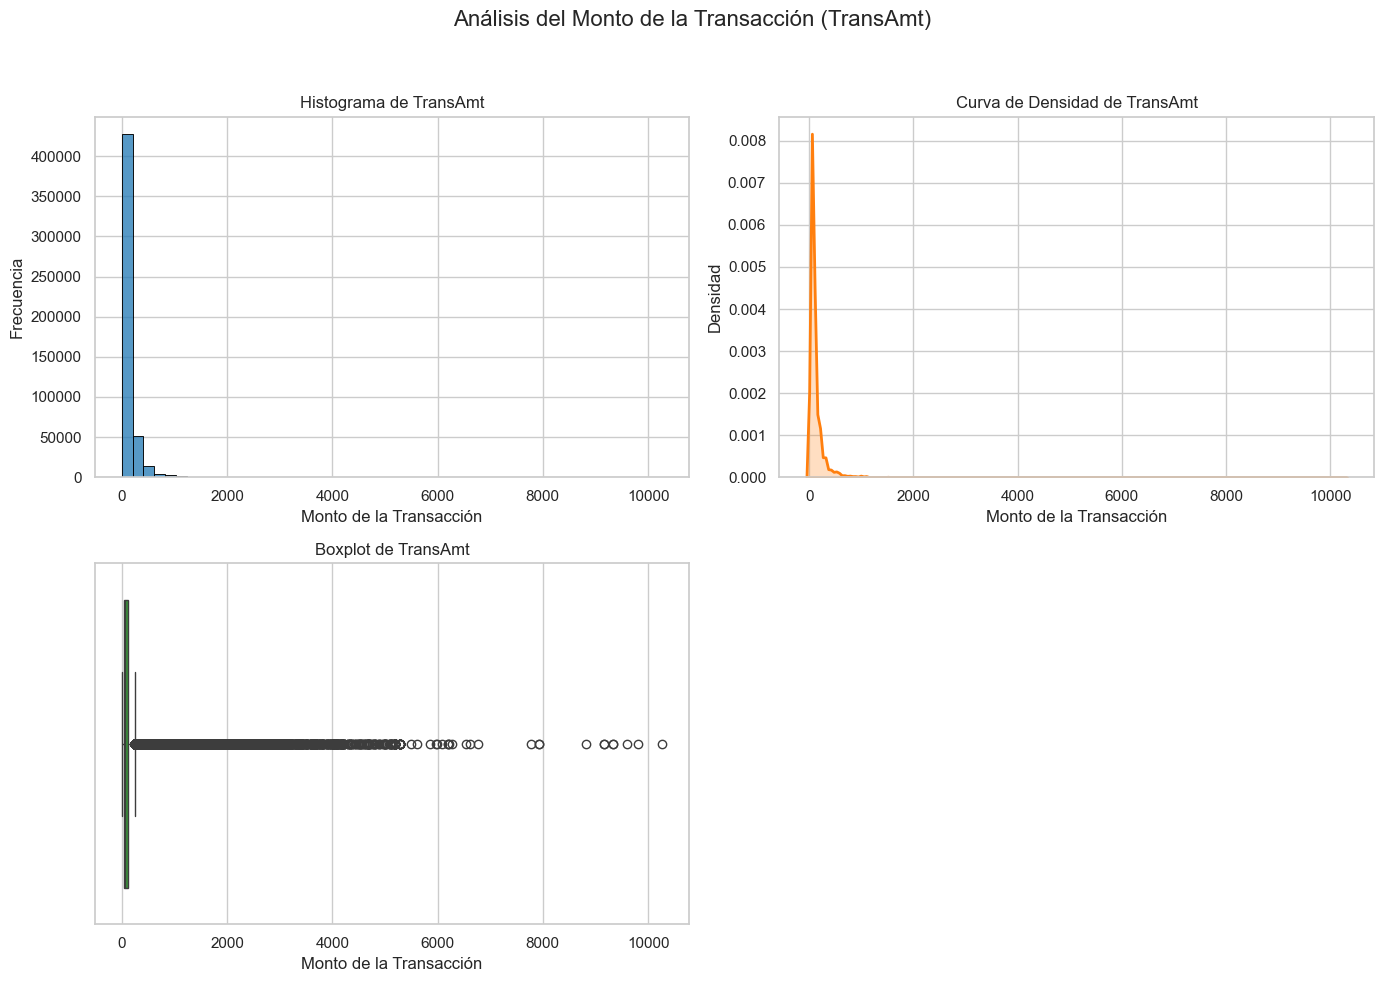

In [12]:
# Estilo general
import seaborn as sns
import matplotlib.pyplot as plt  # Importar matplotlib.pyplot para evitar el NameError
sns.set(style="whitegrid")

# ========================
# Parte 1: TransAmt (histograma + curva de densidad + boxplot)
# ========================
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Análisis del Monto de la Transacción (TransAmt)', fontsize=16)

# Histograma
sns.histplot(FD2['TransAmt'], bins=50, kde=False,
             color='#1f77b4', edgecolor='black', ax=axes1[0, 0])
axes1[0, 0].set_title('Histograma de TransAmt')
axes1[0, 0].set_xlabel('Monto de la Transacción')
axes1[0, 0].set_ylabel('Frecuencia')

# Curva de densidad
sns.kdeplot(FD2['TransAmt'], fill=True, color='#ff7f0e', linewidth=2, ax=axes1[0, 1])
axes1[0, 1].set_title('Curva de Densidad de TransAmt')
axes1[0, 1].set_xlabel('Monto de la Transacción')
axes1[0, 1].set_ylabel('Densidad')

# Boxplot
sns.boxplot(x=FD2['TransAmt'], color='#2ca02c', ax=axes1[1, 0])
axes1[1, 0].set_title('Boxplot de TransAmt')
axes1[1, 0].set_xlabel('Monto de la Transacción')

# Eliminar el cuarto gráfico (vacío)
fig1.delaxes(axes1[1, 1])

# Ajustar diseño
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

El colectivo de analistas examinó la distribución del monto de transacciones (TransAmt) en el conjunto de datos de detección de fraude, revelando un patrón altamente asimétrico. El histograma muestra una concentración extrema de transacciones en valores bajos (menores a $1,000), con más de 400,000 casos en el primer intervalo, seguido por una rápida disminución en frecuencia. La curva de densidad confirma esta asimetría positiva, mostrando un pico pronunciado cerca de cero y una larga cola hacia la derecha. El diagrama de caja (boxplot) ilustra claramente la presencia de numerosos valores atípicos que se extienden hasta $10,000, mientras que la mayoría de los datos se concentran en un rango muy estrecho cerca del primer cuartil. Esta distribución altamente sesgada, con valores extremos dispersos, confirma nuestro análisis previo de asimetría (8.60) y curtosis (129.34) para TransAmt, sugiriendo la necesidad de transformaciones logarítmicas antes del modelado para normalizar esta variable.

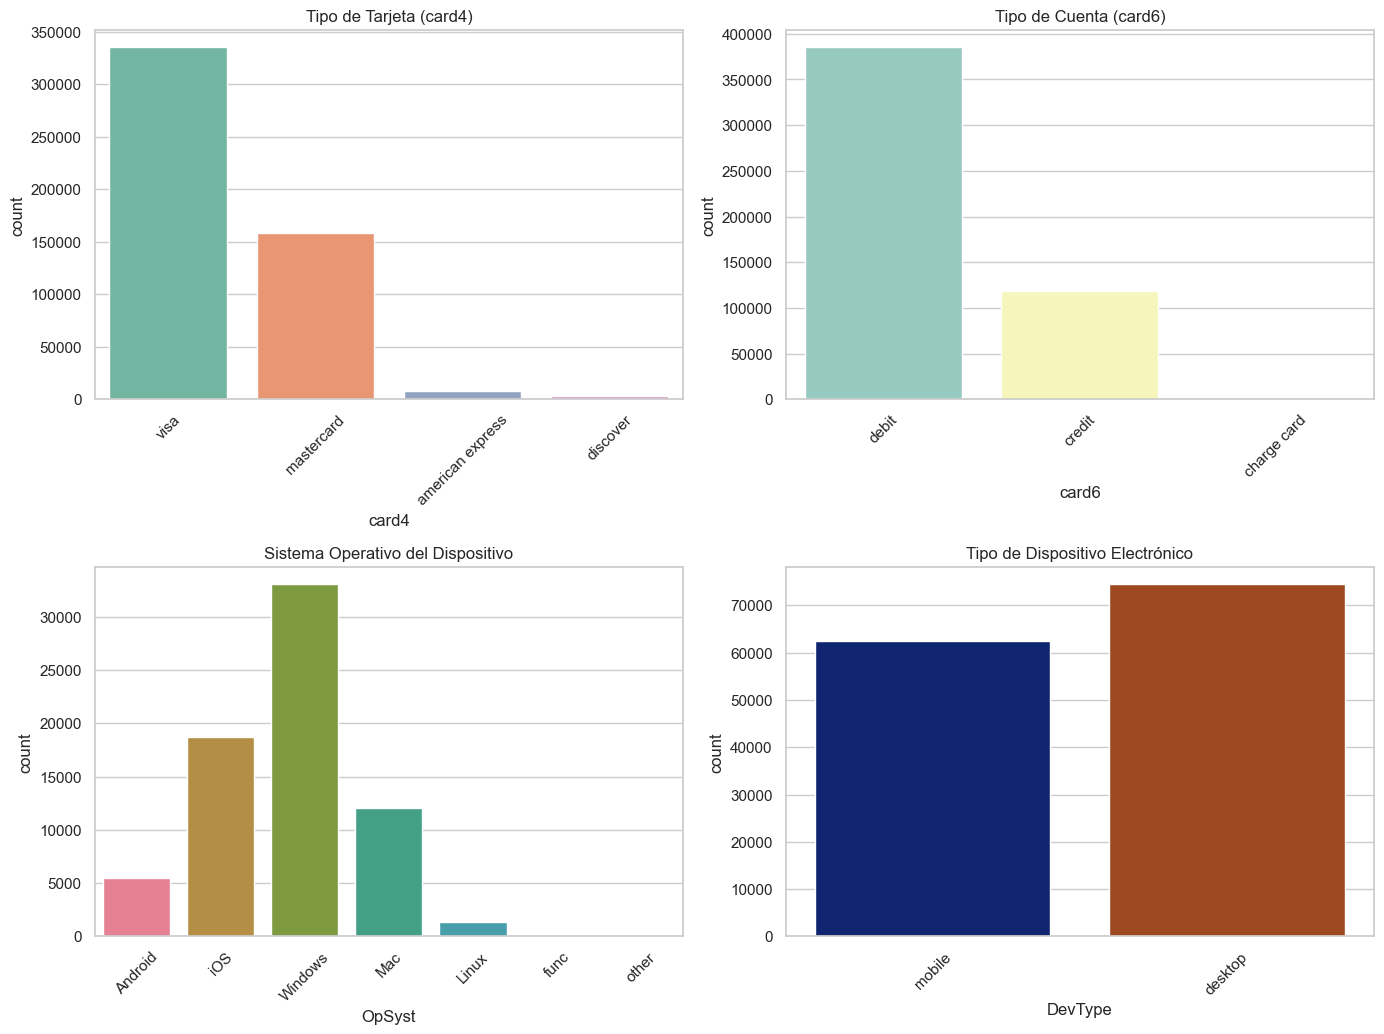


Tiempos de ejecución:
                          Descripción     Tiempo Transcurrido
0           Creación de figura y ejes  0 minutos y 1 segundos
1              Generación de gráficos  0 minutos y 8 segundos
2  Ajuste y visualización de gráficos  0 minutos y 1 segundos


In [13]:
#-------------------------------------------------------------------------
# Importar los paquetes necesarios
#-------------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
import time

#-------------------------------------------------------------------------
# Estilo general
#-------------------------------------------------------------------------
sns.set(style="whitegrid")

#-------------------------------------------------------------------------
# 1. Crear figura y ejes: 3 filas x 2 columnas
#-------------------------------------------------------------------------
# Lista para almacenar los tiempos de ejecución
execution_times = []

start_time = time.time()  # Iniciar el cronómetro

fig2, axes2 = plt.subplots(3, 2, figsize=(14, 15))
axes2 = axes2.flatten()

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Creación de figura y ejes", elapsed_time))

#-------------------------------------------------------------------------
# 2. Generar gráficos categóricos
#-------------------------------------------------------------------------
start_time = time.time()  # Iniciar el cronómetro



# Gráfico 2: card4 (tipo de tarjeta)
sns.countplot(x='card4', data=FD2, ax=axes2[0], hue='card4', palette='Set2', legend=False)
axes2[0].set_title('Tipo de Tarjeta (card4)')
axes2[0].tick_params(axis='x', rotation=45)

# Gráfico 3: card6 (tipo de cuenta)
sns.countplot(x='card6', data=FD2, ax=axes2[1], hue='card6', palette='Set3', legend=False)
axes2[1].set_title('Tipo de Cuenta (card6)')
axes2[1].tick_params(axis='x', rotation=45)

# Gráfico 4: OpSyst (sistema operativo)
sns.countplot(x='OpSyst', data=FD2, ax=axes2[2], hue='OpSyst', palette='husl', legend=False)
axes2[2].set_title('Sistema Operativo del Dispositivo')
axes2[2].tick_params(axis='x', rotation=45)

# Gráfico 5: DevType (tipo de dispositivo)
sns.countplot(x='DevType', data=FD2, ax=axes2[3], hue='DevType', palette='dark', legend=False)
axes2[3].set_title('Tipo de Dispositivo Electrónico')
axes2[3].tick_params(axis='x', rotation=45)

# Eliminar el sexto gráfico (vacío)
fig2.delaxes(axes2[5])
fig2.delaxes(axes2[4])

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Generación de gráficos", elapsed_time))

#-------------------------------------------------------------------------
# 3. Ajustar diseño y mostrar gráficos
#-------------------------------------------------------------------------
start_time = time.time()  # Iniciar el cronómetro

plt.tight_layout()
plt.show()

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Ajuste y visualización de gráficos", elapsed_time))

#-------------------------------------------------------------------------
# 4. Mostrar los tiempos de ejecución en una tabla
#-------------------------------------------------------------------------
# Convertir los tiempos a minutos y segundos
formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

# Crear un DataFrame para mostrar los tiempos
times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


El equipo de investigación analizó las características tecnológicas y financieras de las transacciones, revelando patrones definidos en las preferencias de los usuarios. En cuanto a tipos de tarjetas, Visa domina claramente (más de 330,000 transacciones) sobre Mastercard (aproximadamente 160,000), mientras American Express y Discover representan segmentos mínimos del mercado. Respecto al tipo de cuenta, las tarjetas de débito son ampliamente predominantes (cerca de 385,000 transacciones) frente a las de crédito (aproximadamente 115,000), con las tarjetas de cargo prácticamente inexistentes. El análisis del entorno tecnológico muestra que Windows es el sistema operativo más común (más de 32,000 instancias), seguido por iOS (18,000), Mac (12,000) y Android (5,000), con Linux y otros sistemas teniendo presencia marginal. En cuanto a dispositivos, hay una ligera predominancia de equipos de escritorio (aproximadamente 74,000) sobre dispositivos móviles (62,000). Estos patrones de uso podrían ser relevantes para identificar comportamientos atípicos en transacciones potencialmente fraudulentas.

Tabla de Categoria de la Variable ProdCD

| Código | Posible Significado                           |
|--------|-----------------------------------------------|
| A      | Débito automático                             |
| B      | Compra con tarjeta en punto físico            |
| C      | Retiro de efectivo                            |
| D      | Transferencia entre cuentas                   |
| E      | Pago de servicios                             |
| F      | Compra en línea                               |
| G      | Transacción en cajero automático              |
| H      | Pago de tarjeta de crédito                    |
| I      | Pago por banca móvil                          |
| J      | Envío de dinero                               |
| K      | Compra en comercio internacional              |
| L      | Carga de saldo (prepago, celular, etc.)       |
| M      | Transacción sospechosa                        |
| N      | Reverso o anulación de transacción            |
| O      | Transferencia a terceros                      |
| P      | Préstamo o crédito                            |
| Q      | Pago de impuestos                             |
| R      | Recarga o abono                               |
| S      | Suscripción automática                        |
| T      | Transferencia programada                      |
| U      | Transacción fallida                           |
| V      | Venta o reembolso                             |
| W      | Transacción web / comercio electrónico        |
| X      | Transacción externa                           |
| Y      | Validación o prueba                           |
| Z      | Cierre de cuenta o saldo final                |


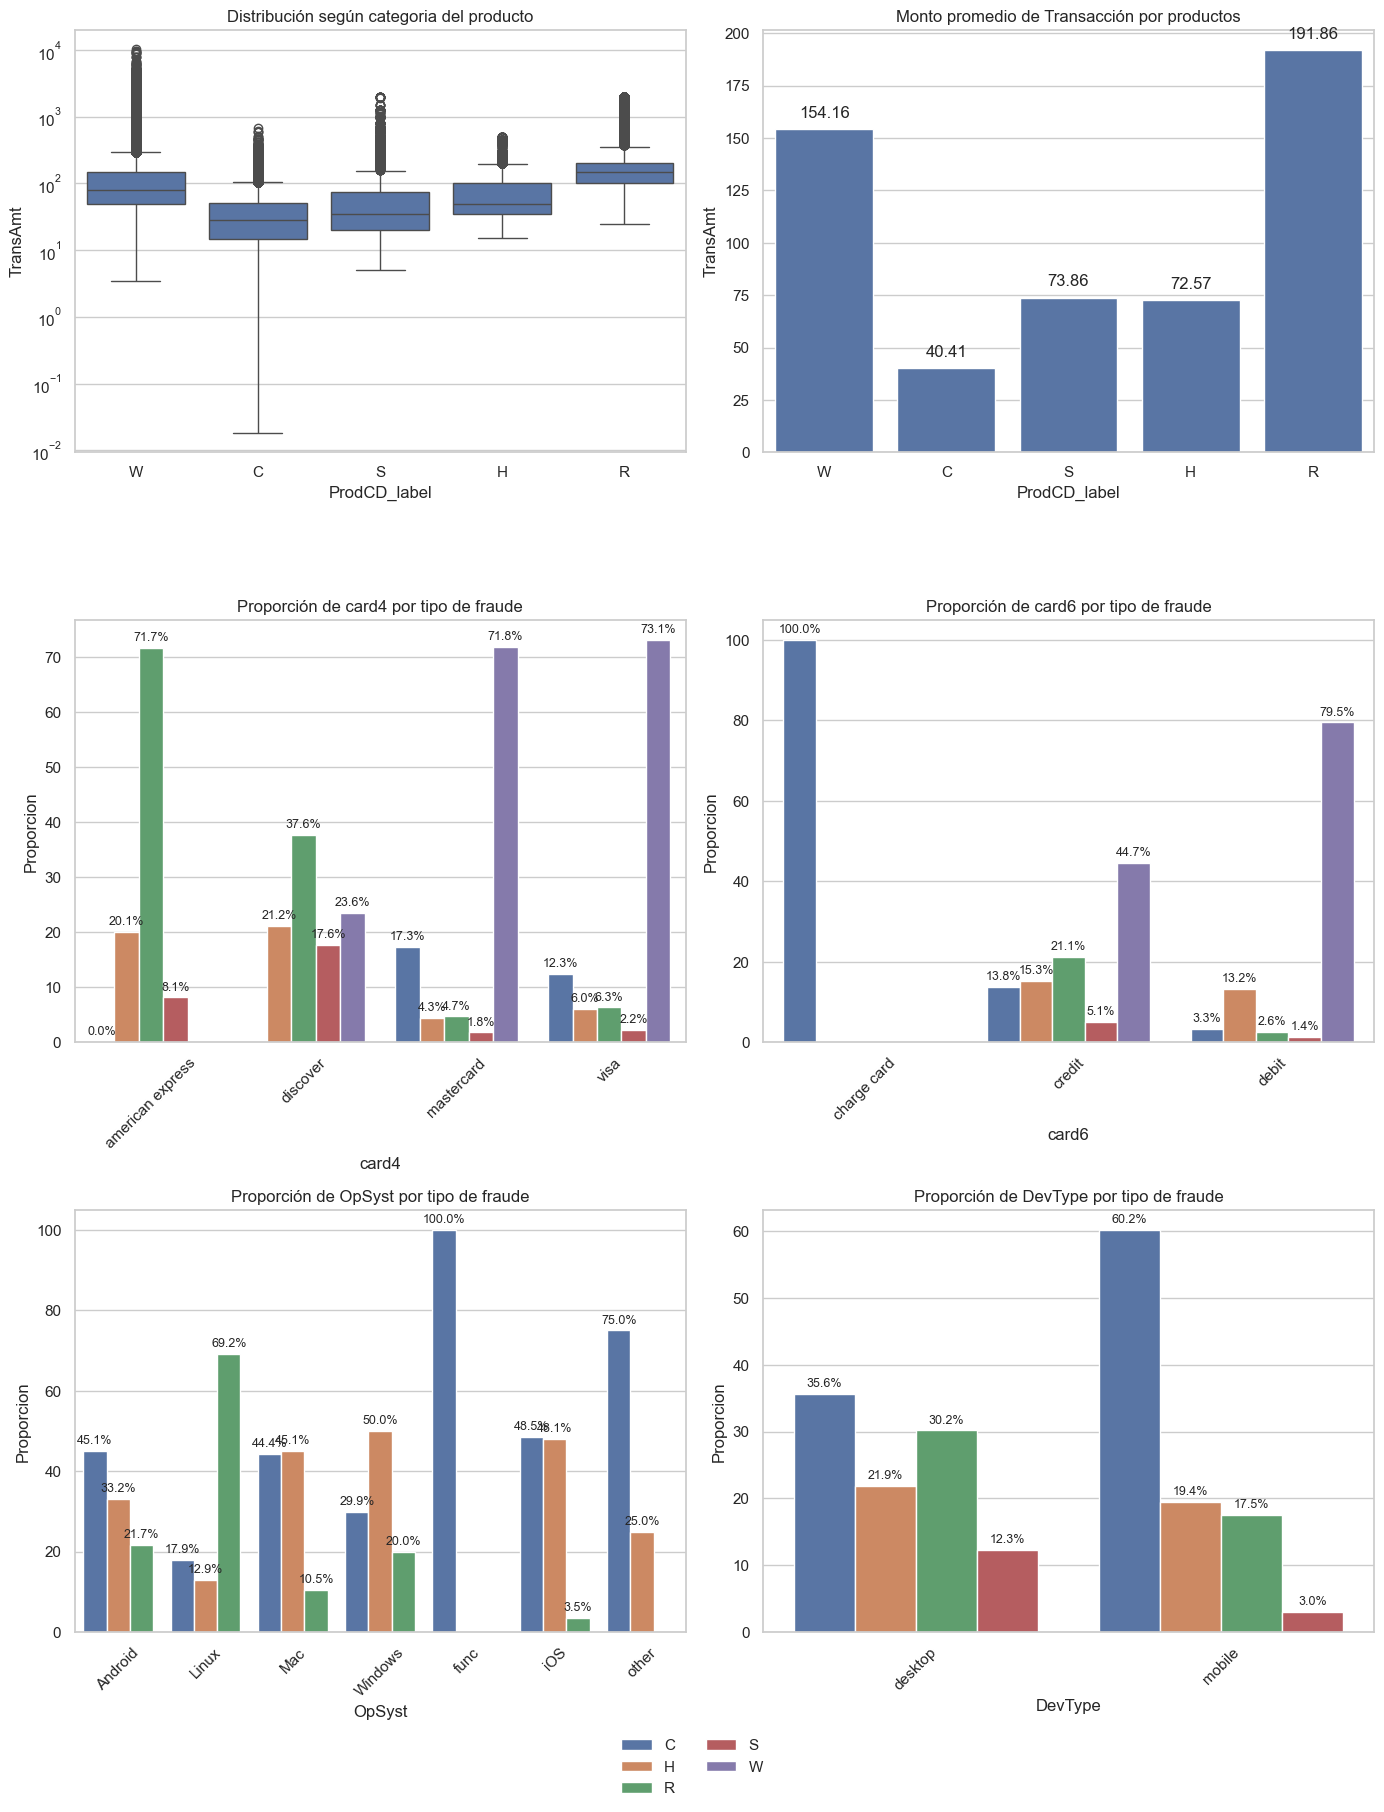

In [34]:
# Estilo general
sns.set(style="whitegrid")

# Variables categóricas y limpieza
variables = ['card4', 'card6', 'OpSyst', 'DevType']
FD2.columns = FD2.columns.str.strip()
FD2['ProdCD_label'] = FD2['ProdCD']

# Verificamos columnas disponibles
columnas_disponibles = FD2.columns.tolist()
variables_existentes = [v for v in variables if v in columnas_disponibles]

# Crear figura 3x2
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

# Guardar handles de la leyenda para usar después
handles_global = None
labels_global = None

# Gráfico 1: Boxplot - Distribución de montos
sns.boxplot(data=FD2, x='ProdCD_label', y='TransAmt', ax=axes[0])
axes[0].set_title('Distribución según categoria del producto')
axes[0].set_yscale('log')  # Escala logarítmica para manejar valores extremos

# Gráfico 2: Barplot - Monto promedio
sns.barplot(data=FD2, x='ProdCD_label', y='TransAmt', errorbar=None, ax=axes[1])
axes[1].set_title('Monto promedio de Transacción por productos')

# Etiquetas sobre las barras del gráfico 2
max_y1 = axes[1].get_ylim()[1]
for p in axes[1].patches:
    height = p.get_height()
    axes[1].text(p.get_x() + p.get_width() / 2, height + 0.02 * max_y1,
                 f'{height:,.2f}', ha='center', va='bottom')

# Gráficos proporcionales
for i, var in enumerate(variables_existentes, start=2):
    counts = FD2.groupby([var, 'ProdCD_label']).size().rename("conteo").reset_index()
    total = counts.groupby(var)['conteo'].transform('sum')
    counts['Proporcion'] = (counts['conteo'] / total) * 100

    ax = axes[i]
    barplot = sns.barplot(data=counts, x=var, y='Proporcion', hue='ProdCD_label', ax=ax)
    ax.set_title(f'Proporción de {var} por tipo de fraude')
    ax.tick_params(axis='x', rotation=45)

    if handles_global is None:
        handles_global, labels_global = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    # Etiquetas sobre las barras
    max_y = ax.get_ylim()[1]
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            ax.text(p.get_x() + p.get_width() / 2, height + 0.01 * max_y,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Eliminar ejes vacíos si sobran
for j in range(len(variables_existentes) + 2, len(axes)):
    fig.delaxes(axes[j])

# Añadir leyenda global (abajo centrada)
fig.legend(handles=handles_global, labels=labels_global, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 1])  # Espacio inferior para la leyenda
plt.show()

El consorcio de análisis identificó patrones significativos al relacionar características del producto y tecnología con posibles indicadores de fraude. La distribución de montos por categoría del producto (ProdCD) muestra que los productos tipo "R" tienen el valor promedio más alto ($191.86), seguidos por "W" ($154.16), mientras que los productos "C" presentan el promedio más bajo ($40.41). Al examinar patrones de fraude por tipo de tarjeta (card4), observamos que las tarjetas Visa y Mastercard están asociadas con mayor proporción de transacciones clasificadas como "W" (73.1% y 71.8% respectivamente), mientras que American Express muestra alta asociación con "R" (71.7%). En cuanto al tipo de cuenta (card6), las tarjetas de crédito muestran mayor proporción de clasificación "W" (44.7%) comparado con débito (79.5%). Respecto a entornos tecnológicos, Linux muestra la mayor proporción de productos "R" (69.2%), mientras que los dispositivos móviles presentan mayor proporción de productos "C" (60.2%) que los de escritorio (35.6%). Estos patrones de asociación proporcionan insights valiosos para mejorar la precisión de los modelos de detección de fraude.

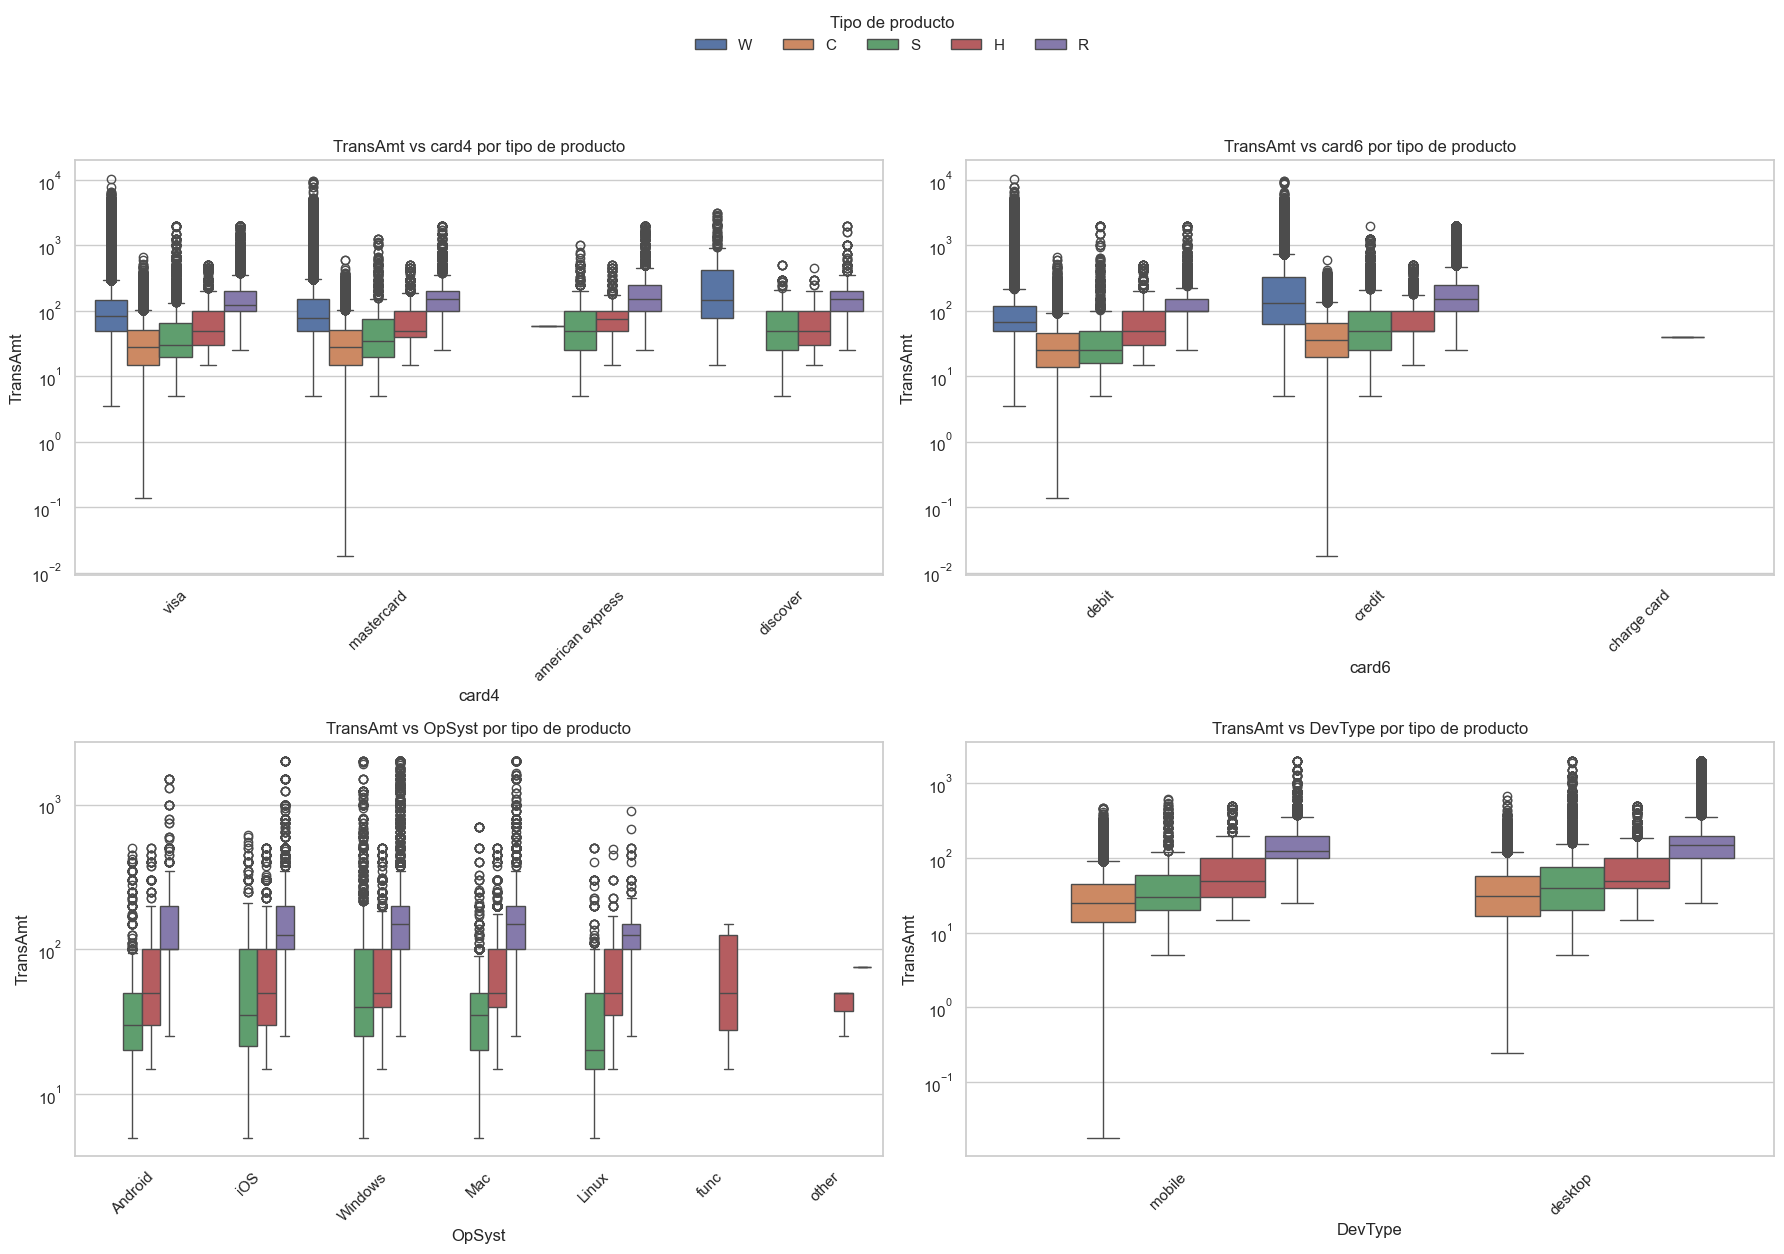

In [40]:
# Asegurar que la variable ProdCD_label existe
FD2['ProdCD_label'] = FD2['ProdCD']

# Estilo
sns.set(style="whitegrid")

# Variables categóricas a comparar con TransAmt
variables = ['card4', 'card6', 'OpSyst', 'DevType']

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Generar los boxplots con hue
for i, var in enumerate(variables):
    sns.boxplot(data=FD2, x=var, y='TransAmt', hue='ProdCD_label', ax=axes[i])
    axes[i].set_title(f'TransAmt vs {var} por tipo de producto')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_yscale('log')  # Escala log para valores extremos
    axes[i].legend_.remove()  # Eliminar leyenda de cada gráfico individual

# Añadir una única leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Tipo de producto', loc='upper center',
           bbox_to_anchor=(0.5, 1.05), ncol=5, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Deja espacio arriba para la leyenda global
plt.show()


El grupo especializado analizó las relaciones entre montos de transacción (TransAmt) y diversos factores tecnológicos y financieros, revelando patrones distintos según el tipo de producto. Los gráficos muestran que los productos tipo "W" y "R" consistentemente presentan montos de transacción más elevados que los tipos "C", "S" y "H" en todas las categorías analizadas. Al examinar la relación con card4, observamos que tanto Visa como Mastercard muestran rangos de valores más amplios para productos "W" y "R", mientras que American Express muestra montos más concentrados. Similar patrón aparece con card6, donde las tarjetas de crédito exhiben valores más altos para productos "W" y "R" que las de débito. Respecto a factores tecnológicos, los montos de transacción para productos "W" son notablemente más altos en entornos Windows que en otros sistemas operativos, y se mantienen relativamente consistentes entre dispositivos móviles y de escritorio. Los datos también revelan mayor presencia de valores atípicos (outliers) para transacciones de alto valor en productos "W" a través de todas las plataformas, sugiriendo posibles indicadores de comportamientos inusuales que podrían ser relevantes para la detección de fraude.
